In [3]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings 
from mlxtend.plotting import plot_decision_regions
from matplotlib.colors import ListedColormap
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Dense 
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles
import seaborn as sns




In [6]:
X,y = make_circles(n_samples=100, noise=0.1, random_state=1)

<Axes: >

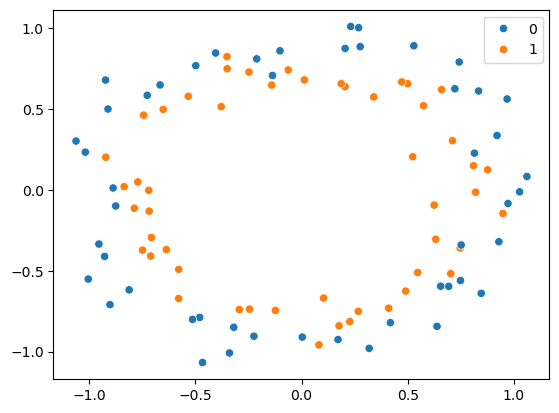

In [9]:
sns.scatterplot(x=X[:,0], y=X[:,1], hue=y)

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20, random_state=2)

In [15]:
model = Sequential()

model.add(Dense(256, input_dim=2, activation = 'relu'))
model.add(Dense(1, activation = 'sigmoid'))


c:\Users\Mr.user\anaconda3\envs\ml\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
model.compile(loss='binary_crossentropy',optimizer='adam', metrics=['accuracy'])

In [19]:
history = model.fit(X_train,y_train, validation_data=(X_test,y_test),epochs=1500,verbose=0)


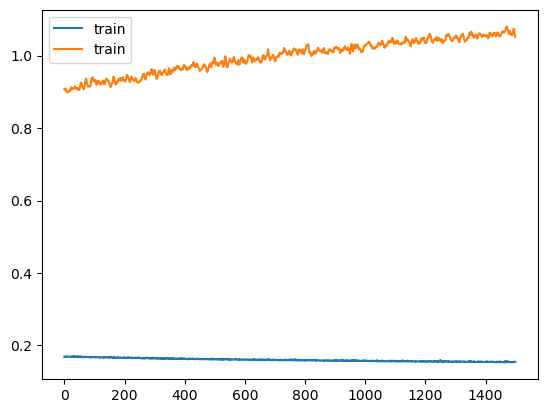

In [22]:
plt.plot(history.history['loss'],label='train')
plt.plot(history.history['val_loss'],label='train')
plt.legend()
plt.show()

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 9s 952us/step


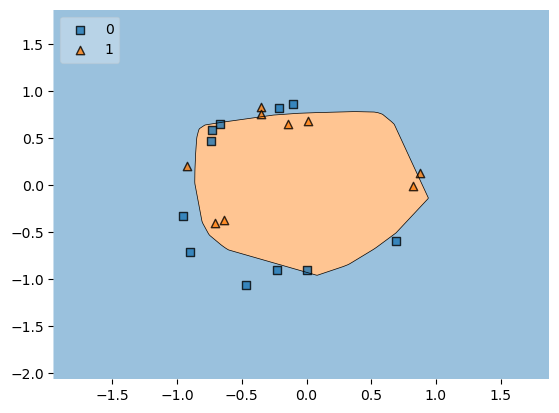

In [24]:
plot_decision_regions(X_test, y_test.ravel(), clf = model, legend=2)
plt.show()

Early Stopping

In [25]:
model = Sequential()

model.add(Dense(256, input_dim=2, activation = 'relu'))
model.add(Dense(1, activation = 'sigmoid'))

c:\Users\Mr.user\anaconda3\envs\ml\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [26]:
model.compile(loss='binary_crossentropy',optimizer='adam', metrics=['accuracy'])

In [29]:
callback = EarlyStopping(
    monitor="val_loss",
    min_delta=0.00001,
    patience=20,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=False
)

In [33]:
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=1500, callbacks=callback)


Epoch 1/1500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.9250 - loss: 0.1856 - val_accuracy: 0.6500 - val_loss: 0.7402
Epoch 2/1500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.9125 - loss: 0.1858 - val_accuracy: 0.6500 - val_loss: 0.7412
Epoch 3/1500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9125 - loss: 0.1853 - val_accuracy: 0.6500 - val_loss: 0.7378
Epoch 4/1500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9125 - loss: 0.1849 - val_accuracy: 0.6500 - val_loss: 0.7342
Epoch 5/1500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9125 - loss: 0.1857 - val_accuracy: 0.6500 - val_loss: 0.7318
Epoch 6/1500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.9125 - loss: 0.1852 - val_accuracy: 0.6500 - val_loss: 0.7340
Epoch 7/1500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9250 - loss: 0.1854 - val_accuracy: 0.6500 - val_loss: 0.7359
Epoch 8/1500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9250 - loss: 0.1855 - val_accuracy: 0.6500 - v

This is main concept in Early stopping on 15 epoch training is stop --> on these 15 epoch give best answer otherwise cause overfitting 

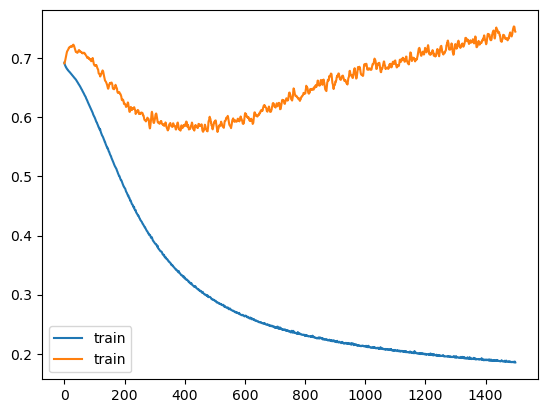

In [31]:
plt.plot(history.history['loss'],label='train')
plt.plot(history.history['val_loss'],label='train')
plt.legend()
plt.show()

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 9s 912us/step


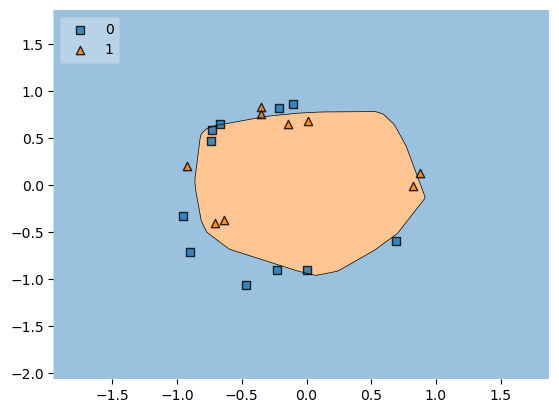

In [32]:
plot_decision_regions(X_test, y_test.ravel(), clf = model, legend=2)
plt.show()